In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from model.classifier import Classifier, MyProgressBar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.set_float32_matmul_precision('high')

In [3]:
from utils.transform_sequence import TransformSequence
from utils.transforms.apply import grid_resample
from utils.affine_transforms import AffineTransformation2D

transformations = [AffineTransformation2D.ROTATION.value]
domains = [(-torch.pi,torch.pi),]
n_samples = 17

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)

In [4]:
transform_seq_learnable= TransformSequence([AffineTransformation2D.ROTATION_COMPLEX.value], [(-1,1.0),], neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)

In [5]:
from its.transform import multi_transform
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.




def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


# Create transformed datasets for both training and testing
dataset_train_transformed = AffineTransformDataset(dataset_train, transform, return_transformation=False, batch_size=batch_size)


In [6]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4, persistent_workers=True)

# Create data loader for transformed training data
train_transformed_loader = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4, persistent_workers=True)


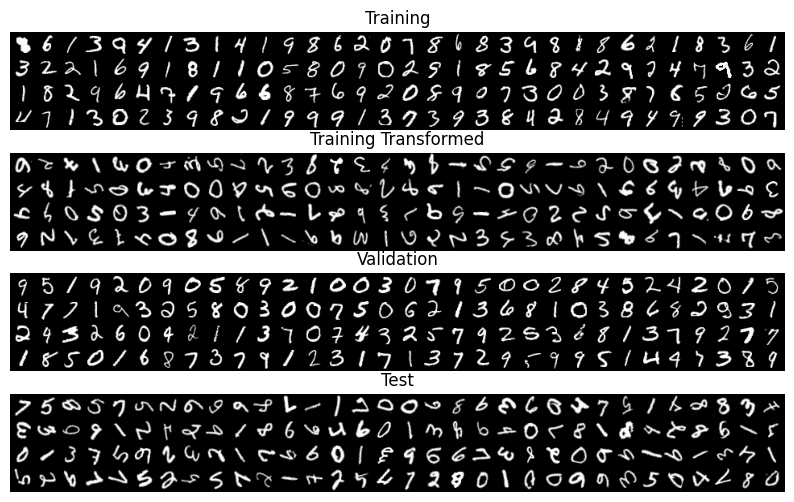

In [7]:
#test images
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(10, 6))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(train_transformed_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[3].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Training Transformed')
axs[2].set_title('Validation')
axs[3].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [8]:
import pytorch_lightning as pl
import os

model_path = f'../model/{dataset}_rot_only.pth'

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Loading model from ../model/mnist_rot_only.pth


In [11]:

from equiadapt.images.canonicalization.continuous_group import OptimizedSteerableImageCanonicalization

from omegaconf import OmegaConf

canonicalization_network = torch.nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x7x7
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x3x3
    nn.Conv2d(32, 128, kernel_size=3, stride=1, padding=0),  # Output: 64x1x1
    nn.BatchNorm2d(128),                                    # Batch Normalization
    nn.GELU(),
    nn.Flatten(),
    nn.Linear(128, 16),
)


dict_config = OmegaConf.create({
    "beta": 1.0,
    "maximum_frequency": 3,
    "group_type": "rotation",
    "num_rotations": 17,
    "artifact_err_wt": False,
    "resize_shape": (1, 28, 28),
    "learn_ref_vec": False,
})

canonicalizer = OptimizedSteerableImageCanonicalization(canonicalization_network,
                                                        dict_config, (1, 28, 28)).cuda()
model.cuda()


def test():
    with torch.no_grad():
        avg_acc = 0
        avg_loss = 0
        for batch in tqdm.tqdm(test_loader):
            x, y = batch
            x = x.cuda()
            x_canonicalized = canonicalizer(x)
            logits = model(x_canonicalized)
            output = logits.argmax(dim=-1)
            loss = nn.CrossEntropyLoss()(logits, y.cuda())
            acc = output.eq(y.cuda()).sum().item()
            avg_acc += acc

        avg_acc /= len(dataset_test)
        print(f'Accuracy on the test set after canonicalization: {avg_acc}.')


import tqdm

for i in range(30):
    opt = torch.optim.AdamW(canonicalization_network.parameters(), lr=1e-3)
    for batch in tqdm.tqdm(train_transformed_loader):
        opt.zero_grad()
        x, y = batch
        x = x.cuda()
        x_canonicalized = canonicalizer(x)
        logits = model(x_canonicalized)
        loss = nn.CrossEntropyLoss()(logits, y.cuda())
        loss += canonicalizer.get_prior_regularization_loss() * 0.0
        loss += canonicalizer.get_optimization_specific_loss() * 0.000
        loss.backward()
        opt.step()
    test()



100%|██████████| 40/40 [00:00<00:00, 269.35it/s]


Accuracy on the test set after canonicalization: 0.838.


100%|██████████| 40/40 [00:00<00:00, 258.87it/s]


Accuracy on the test set after canonicalization: 0.877.


100%|██████████| 40/40 [00:00<00:00, 283.47it/s]


...

Accuracy on the test set after canonicalization: 0.9366.


100%|██████████| 40/40 [00:00<00:00, 263.18it/s]


Accuracy on the test set after canonicalization: 0.938.


100%|██████████| 40/40 [00:00<00:00, 262.11it/s]

Accuracy on the test set after canonicalization: 0.934.


In [12]:
from torch import nn

In [18]:
# Define localization network for spatial transformer
localization_net = torch.nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Output: 64x7x7
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x3x3
    nn.Conv2d(32, 128, kernel_size=3, stride=1, padding=0),  # Output: 64x1x1
    nn.BatchNorm2d(128),                                    # Batch Normalization
    nn.GELU(),
    nn.Flatten(),
    nn.Linear(128, 2),
)

# Calculate the output dimension of the localization network
with torch.no_grad():
    dummy_input = torch.zeros(1, 1, 28, 28)
    loc_output = localization_net(dummy_input)
    localization_dim = loc_output.numel()  # Get the flattened size
    print(f"Localization network output dimension: {localization_dim}")

# Create spatial transformer model (6 parameters for 2D affine transformation)
spatial_model_path = f'../model/{dataset}_gmm_reg2.py'

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 128, 1, 1])

In [19]:
transforms_comlex= [
    AffineTransformation2D.ROTATION_COMPLEX.value,
]
domains_complex = [(-10000000,10000000),]
transform_seq_complex_number = TransformSequence(transforms_comlex, domains_complex, neighbour_hood_size=0.25, application_method=grid_resample, device=device, reflect=True, use_individual_param_correction=False)



from utils.transformation_problem import TransformationProblem


from model.spatial_transformer_classifier import SpatialTransformerClassifier



# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and False:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq_complex_number),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    spatial_transformer = SpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq_complex_number),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-3},
        optimizer_class = torch.optim.AdamW,
        use_l2_instead_of_per_transform = True,
        l2_weight= 0.001,
    )
    restore_best_model = pl.callbacks.ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True
    )

    # Train the spatial transformer model on transformed data
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=40,
        precision="16-mixed",
        callbacks=[MyProgressBar(), restore_best_model],
        enable_checkpointing=True,
    )

    trainer.fit(spatial_transformer, train_transformed_loader, test_loader)
    #restore best checkpoint
    best_ckpt_path = restore_best_model.best_model_path
    print(f"Loading best model checkpoint from: {best_ckpt_path}")
    spatial_transformer = SpatialTransformerClassifier.load_from_checkpoint(best_ckpt_path)


    # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type       | Params | Mode 
--------------------------------------------------------
0 | main_model       | Sequential | 421 K  | eval 
1 | localization_net | Sequential | 56.5 K | train
2 | regression_net   | Linear     | 6      | train
--------------------------------------------------------
56.5 K    Trainable params
421 K     Non-trainable params
478 K     Total params
1.913     Total estimated model params size (MB)
19        Modules in train mode
11        Modules in eval mode


Training spatial transformer model and will save to ../model/mnist_gmm_reg2.py
Epoch 0: 100%|██████████| 469/469 [00:12<00:00, 37.04it/s, v_num=181, train_loss=2.000, train_reg=2.11e-5, val_loss=1.760, val_reg=2.08e-5, val_acc=0.787]

Epoch 0, global step 469: 'val_acc' reached 0.78720 (best 0.78720), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\lightning_logs\\version_181\\checkpoints\\epoch=0-step=469.ckpt' as top 1


Epoch 1: 100%|██████████| 469/469 [00:08<00:00, 54.86it/s, v_num=181, train_loss=0.505, train_reg=2.82e-5, val_loss=0.949, val_reg=3.22e-5, val_acc=0.877]

Epoch 1, global step 938: 'val_acc' reached 0.87720 (best 0.87720), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\lightning_logs\\version_181\\checkpoints\\epoch=1-step=938.ckpt' as top 1


...

Epoch 38, global step 18291: 'val_acc' was not in top 1


Epoch 39: 100%|██████████| 469/469 [00:07<00:00, 61.53it/s, v_num=181, train_loss=0.082, train_reg=0.000947, val_loss=0.204, val_reg=0.000924, val_acc=0.962]

Epoch 39, global step 18760: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=40` reached.


Epoch 39: 100%|██████████| 469/469 [00:07<00:00, 61.50it/s, v_num=181, train_loss=0.082, train_reg=0.000947, val_loss=0.204, val_reg=0.000924, val_acc=0.962]
Loading best model checkpoint from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\lightning_logs\version_181\checkpoints\epoch=35-step=16884.ckpt


TypeError: SpatialTransformerClassifier.__init__() missing 4 required positional arguments: 'main_model', 'localization_net', 'localization_dim', and 'transformation_problem'



  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 1/469 [00:02<22:08,  2.84s/it]

  1%|          | 4/469 [00:02<04:24,  1.76it/s]

  3%|▎         | 13/469 [00:03<01:02,  7.33it/s]

  6%|▌         | 26/469 [00:03<00:25, 17.47it/s]

  8%|▊         | 39/469 [00:03<00:14, 29.27it/s]

 11%|█▏        | 53/469 [00:03<00:09, 43.35it/s]

 14%|█▍        | 66/469 [00:03<00:07, 56.83it/s]

 17%|█▋        | 78/469 [00:03<00:05, 68.03it/s]

 19%|█▉        | 91/469 [00:03<00:04, 80.24it/s]

 22%|██▏       | 103/469 [00:03<00:04, 89.19it/s]

 25%|██▍       | 116/469 [00:03<00:03, 97.75it/s]

 28%|██▊       | 130/469 [00:03<00:03, 106.65it/s]

 30%|███       | 143/469 [00:04<00:02, 110.99it/s]

 33%|███▎      | 156/469 [00:04<00:02, 113.06it/s]

 36%|███▌      | 169/469 [00:04<00:02, 116.43it/s]

 39%|███▉      | 182/469 [00:04<00:02, 119.57it/s]

 42%|████▏     | 195/469 [00:04<00:02, 118.28it/s]

 44%|████▍     | 208/469 [00:04<00:02, 119.11it/s]

 47%|████▋     | 221/469 [00:04<00:02, 117.

Accuracy on the test set after canonicalization: 0.097.




  0%|          | 0/469 [00:00<?, ?it/s]

  2%|▏         | 10/469 [00:00<00:04, 93.41it/s]

  4%|▍         | 21/469 [00:00<00:04, 101.93it/s]

  7%|▋         | 33/469 [00:00<00:03, 109.77it/s]

 10%|▉         | 45/469 [00:00<00:03, 111.98it/s]

 13%|█▎        | 59/469 [00:00<00:03, 120.48it/s]

 16%|█▌        | 73/469 [00:00<00:03, 124.61it/s]

 19%|█▉        | 88/469 [00:00<00:02, 130.01it/s]

 22%|██▏       | 101/469 [00:00<00:02, 129.98it/s]

 25%|██▍       | 115/469 [00:00<00:02, 130.80it/s]

 28%|██▊       | 129/469 [00:01<00:02, 128.97it/s]

 30%|███       | 143/469 [00:01<00:02, 129.48it/s]

 33%|███▎      | 156/469 [00:01<00:02, 127.92it/s]

 36%|███▌      | 169/469 [00:01<00:02, 124.75it/s]

 39%|███▉      | 182/469 [00:01<00:02, 124.76it/s]

 42%|████▏     | 195/469 [00:01<00:02, 122.13it/s]

 44%|████▍     | 208/469 [00:01<00:02, 121.85it/s]

 47%|████▋     | 222/469 [00:01<00:01, 124.50it/s]

 50%|█████     | 235/469 [00:01<00:01, 123.64it/s]

 53%|█████▎    | 248/469 [00:

Accuracy on the test set after canonicalization: 0.097.




  0%|          | 0/469 [00:00<?, ?it/s]

  2%|▏         | 11/469 [00:00<00:04, 104.11it/s]

  5%|▌         | 24/469 [00:00<00:03, 116.14it/s]

  8%|▊         | 37/469 [00:00<00:03, 121.73it/s]

 11%|█         | 50/469 [00:00<00:03, 121.32it/s]

 13%|█▎        | 63/469 [00:00<00:03, 117.72it/s]

 16%|█▌        | 76/469 [00:00<00:03, 121.39it/s]

 19%|█▉        | 90/469 [00:00<00:03, 126.31it/s]

 22%|██▏       | 103/469 [00:00<00:02, 126.63it/s]

 25%|██▍       | 116/469 [00:00<00:02, 120.96it/s]

 28%|██▊       | 129/469 [00:01<00:02, 121.80it/s]

 30%|███       | 142/469 [00:01<00:02, 122.24it/s]

 33%|███▎      | 156/469 [00:01<00:02, 125.84it/s]

 36%|███▌      | 169/469 [00:01<00:02, 126.47it/s]

 39%|███▉      | 182/469 [00:01<00:02, 126.01it/s]

 42%|████▏     | 195/469 [00:01<00:02, 124.21it/s]

 44%|████▍     | 208/469 [00:01<00:02, 124.36it/s]

 47%|████▋     | 221/469 [00:01<00:01, 125.59it/s]

 50%|████▉     | 234/469 [00:01<00:01, 124.29it/s]

 53%|█████▎    | 247/469 [00

Accuracy on the test set after canonicalization: 0.097.




  0%|          | 0/469 [00:00<?, ?it/s]

  2%|▏         | 11/469 [00:00<00:04, 108.27it/s]

  6%|▌         | 26/469 [00:00<00:03, 130.09it/s]

  9%|▊         | 40/469 [00:00<00:03, 129.72it/s]

 12%|█▏        | 54/469 [00:00<00:03, 132.18it/s]

 14%|█▍        | 68/469 [00:00<00:03, 131.67it/s]

 17%|█▋        | 82/469 [00:00<00:02, 132.55it/s]

 20%|██        | 96/469 [00:00<00:02, 131.74it/s]

 23%|██▎       | 110/469 [00:00<00:02, 130.66it/s]

 26%|██▋       | 124/469 [00:00<00:02, 133.36it/s]

 29%|██▉       | 138/469 [00:01<00:02, 133.21it/s]

 33%|███▎      | 153/469 [00:01<00:02, 135.19it/s]

 36%|███▌      | 167/469 [00:01<00:02, 133.45it/s]

 39%|███▊      | 181/469 [00:01<00:02, 134.49it/s]

 42%|████▏     | 195/469 [00:01<00:02, 135.75it/s]

 45%|████▍     | 209/469 [00:01<00:01, 135.13it/s]

 48%|████▊     | 223/469 [00:01<00:01, 133.41it/s]

 51%|█████     | 237/469 [00:01<00:01, 135.18it/s]

 54%|█████▎    | 251/469 [00:01<00:01, 134.75it/s]

 57%|█████▋    | 265/469 [00

Accuracy on the test set after canonicalization: 0.097.




  0%|          | 0/469 [00:00<?, ?it/s]

  2%|▏         | 10/469 [00:00<00:04, 97.10it/s]

  5%|▍         | 22/469 [00:00<00:04, 106.89it/s]

  7%|▋         | 35/469 [00:00<00:03, 115.79it/s]

 10%|█         | 47/469 [00:00<00:03, 116.08it/s]

 13%|█▎        | 59/469 [00:00<00:03, 115.76it/s]

 15%|█▌        | 71/469 [00:00<00:03, 115.41it/s]

 18%|█▊        | 83/469 [00:00<00:03, 115.48it/s]

 21%|██        | 97/469 [00:00<00:03, 122.75it/s]

 23%|██▎       | 110/469 [00:00<00:02, 121.42it/s]

 28%|██▊       | 129/469 [00:01<00:02, 118.85it/s]

KeyboardInterrupt



In [10]:
model.cuda()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [33]:
def test():
    with torch.no_grad():
        avg_acc = 0
        avg_loss = 0
        for batch in tqdm.tqdm(test_loader):
            x, y = batch
            x = x.cuda()
            x_canonicalized = canonicalizer(x)
            logits = model(x_canonicalized)
            output = logits.argmax(dim=-1)
            loss = nn.CrossEntropyLoss()(logits, y.cuda())
            acc = output.eq(y.cuda()).sum().item()
            avg_acc += acc


        avg_acc /= len(dataset_test)
        print(f'Accuracy on the test set after canonicalization: {avg_acc}.')
import tqdm
for i in range(30):
    opt = torch.optim.AdamW(canonicalization_network.parameters(), lr=1e-2)
    for batch in tqdm.tqdm(train_transformed_loader):
        opt.zero_grad()
        x, y = batch
        x = x.cuda()
        x_canonicalized = canonicalizer(x)
        logits = model(x_canonicalized)
        loss = nn.CrossEntropyLoss()(logits, y.cuda())
        loss += canonicalizer.get_prior_regularization_loss()*1.0
        loss.backward()
        opt.step()
    test()



  0%|          | 0/469 [05:27<?, ?it/s]


KeyboardInterrupt: 

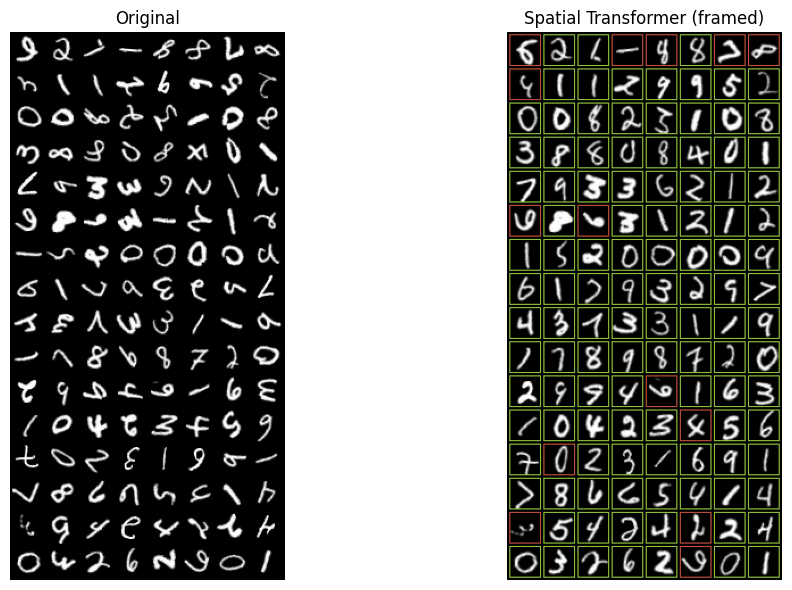

In [12]:
#validate on testset

#validate on testset
#plot some samples
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda(), target.cuda()

    # 2. Apply spatial transformer
    transformed = canonicalizer(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [13]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [14]:
model.cuda()


Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [15]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.989.


In [16]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'9',flatten=True)

In [17]:
#extract embeddings and fit NNDistanceConfidence()
embeddings = []
classes = []
for batch in train_loader:
    emb, _ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())

embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings = embeddings[indices]
    classes = classes[indices]



In [18]:
from confidence.base_confidence import CrossEntropyConfidence,EnergyConfidence
from confidence.unsupervised.ml.nn_pytorch import TorchNNConfidence
from utils.transformation_problem import TransformationProblem

In [19]:
nearest_neighbor_confidence = TorchNNConfidence(per_class=True,number_of_neighbors=3)
nearest_neighbor_confidence.fit(torch.tensor(embeddings, dtype=torch.float,device="cuda"),torch.tensor(classes, dtype=torch.float,device="cuda"))
nearest_neighbor_confidence.cuda()
from confidence.base_confidence import SplitConfidence, SinglePassConfidence
nearest_neighbor_confidence_unguided = TorchNNConfidence(per_class=False,number_of_neighbors=3)
nearest_neighbor_confidence_unguided.fit(embeddings)
nearest_neighbor_confidence_unguided.cuda()


conf_split_guided = SplitConfidence(nearest_neighbor_confidence, CrossEntropyConfidence(), mult=True)
conf_split_unguided = SplitConfidence(nearest_neighbor_confidence_unguided, EnergyConfidence(), mult=True)

In [20]:

conf_guided = SinglePassConfidence(dual_ouput_model, conf_split_guided,index=1)
conf_unguided = SinglePassConfidence(dual_ouput_model, conf_split_unguided,index=1)
problem_guided = TransformationProblem(conf_guided, transform_seq, consolidate_method="consolidate_simple")

problem_unguided = TransformationProblem(conf_unguided, transform_seq, consolidate_method="consolidate_simple")


In [21]:
nearest_neighbor_confidence._train_data = nearest_neighbor_confidence._train_data.cuda()

In [22]:
model.cuda()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [23]:
import search.shgo
import importlib
import tqdm

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
test_acc_sim = 0
stop_at = 1
counter = 0
regression_data = []
regression_target =[]
regression_classes = []

for d, (data, target) in enumerate(tqdm.tqdm(train_transformed_loader)):
    data, target = data.cuda(), target.cuda()
    regression_data.append(data.detach().cpu().numpy())
    res = di.optimize(problem_guided, data.cuda(),y=target.cuda())
    regression_target.append(res[0].detach().cpu().numpy())
    regression_classes.append(target.detach().cpu().numpy())

    # Apply the transformation and get predictions
    x_transformed2 = problem_guided.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'With class knowledge we can define a canonical represenation of the data: {test_acc_sim}.')

100%|██████████| 469/469 [03:10<00:00,  2.47it/s]

With class knowledge we can define a canonical represenation of the data: 0.99975.


In [24]:
regression_target = np.vstack(regression_target)
regression_target = torch.tensor(regression_target, dtype=torch.float32).cpu()
regression_data = np.vstack(regression_data)
regression_data = torch.tensor(regression_data, dtype=torch.float32).cpu()
regression_classes = np.hstack(regression_classes)
regression_classes = torch.tensor(regression_classes, dtype=torch.long).cpu()



In [25]:
#this is very unlikely to work due to noise and symetires.

In [26]:

class RegressionDataset(torch.utils.data.Dataset):
    def __init__(self, data, target_params,y=None):
        self.data = data
        self.target_params = target_params
        self.y = y

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        target_params = self.target_params[idx]
        if self.y is not None:
            y = self.y[idx]
            return x, target_params, y
        else:
            return x, target_params


In [27]:
regression_dataset = RegressionDataset(regression_data, regression_target, regression_classes)
regression_dataloader = torch.utils.data.DataLoader(regression_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

(-0.5, 301.5, 301.5, -0.5)

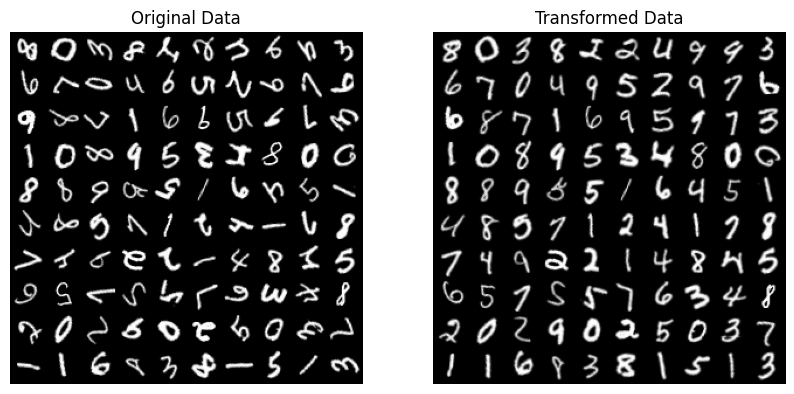

In [28]:
#plot dataset and transformed dataset sample

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
x,p,_ = regression_dataset[:100]

plt.imshow(torchvision.utils.make_grid(x, nrow=10).permute(1, 2, 0).cpu())
plt.title('Original Data')
plt.axis('off')

plt.subplot(1, 2, 2)

x_transformed = transform_seq.transform(x, p)
plt.imshow(torchvision.utils.make_grid(x_transformed, nrow=10).permute(1, 2, 0).cpu())
plt.title('Transformed Data')
plt.axis('off')





In [29]:
# Define localization network for spatial transformer
localization_net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.GELU(),

)

# Calculate the output dimension of the localization network
with torch.no_grad():
    dummy_input = torch.zeros(1, 1, 28, 28)
    loc_output = localization_net(dummy_input)
    localization_dim = loc_output.numel()  # Get the flattened size
    print(f"Localization network output dimension: {localization_dim}")

# Create spatial transformer model (6 parameters for 2D affine transformation)
spatial_model_path = f'../model/{dataset}_gmm_reg4.py'

Localization network output dimension: 128


In [30]:




from utils.transformation_problem import TransformationProblem


from model.pspatial.m_p_spatial import TrainModeSchedulerCallback
from model.pspatial.cvae_spatial import CVAESpatialTransformerClassifier



# Check if spatial transformer model exists
if os.path.exists(spatial_model_path) and True:
    print(f"Loading spatial transformer model from {spatial_model_path}")
    spatial_transformer = CVAESpatialTransformerClassifier(
        main_model=model,
        transformation_problem=TransformationProblem(None,transform_seq),
        localization_net=localization_net,
        localization_dim=localization_dim,
        freeze_main=True,
    )
    spatial_transformer.load_state_dict(torch.load(spatial_model_path))
else:
    print(f"Training spatial transformer model and will save to {spatial_model_path}")
    spatial_transformer = CVAESpatialTransformerClassifier(
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq),
        freeze_main=True,  # Freeze the base model
        optimizer_params={"lr": 1e-3},
        optimizer_class = torch.optim.AdamW,
        l2_weight= 0.01,
        kl_weight=1e-8,
        use_l2_instead_of_per_transform = False,
        train_mode = 1.0,
    )
    train_mode_scheduler = TrainModeSchedulerCallback(
        regression_epochs=30,
        transition_epochs=10,
    )
    restore_best_model = pl.callbacks.ModelCheckpoint(
        monitor='val_acc_mode',
        mode='max',
        save_top_k=1,
        verbose=True,
        filename='best_fspatial_transformer',
    )

    # Train the spatial transformer model on transformed data
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=40,
        precision="16-mixed",
        callbacks=[MyProgressBar(), train_mode_scheduler, restore_best_model],
        enable_checkpointing=True,
    )

    trainer.fit(spatial_transformer, regression_dataloader, test_loader)
    #restore best checkpoint
    best_ckpt_path = restore_best_model.best_model_path
    print(f"Loading best model checkpoint from: {best_ckpt_path}")
    spatial_transformer = CVAESpatialTransformerClassifier.load_from_checkpoint(best_ckpt_path,
        main_model=model,
        localization_net=localization_net,
        localization_dim=localization_dim,
        transformation_problem=TransformationProblem(None,transform_seq),
        freeze_main=True,  # Freeze the base model
    )


    # Save the spatial transformer model
    torch.save(spatial_transformer.state_dict(), spatial_model_path)
    print(f"Spatial transformer model saved to {spatial_model_path}")


Loading spatial transformer model from ../model/mnist_gmm_reg4.py


ValueError: Unknown reg_options: {'kl'}. Valid: {'kl_normal', 'sharpness', 'entropy', 'kl_uniform'}.

In [ ]:
spatial_transformer.cuda()

In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer.transform_input(data)
        logits = model(output)
        st_acc += logits.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')


In [ ]:
import hashlib


def hash_model(model):
    """Compute a SHA256 hash of a PyTorch model's state_dict."""
    # Get the state_dict
    state_dict = model.state_dict()

    # Serialize the state_dict into a single bytes object
    serialized = b"".join(
        tensor.cpu().numpy().tobytes() for tensor in state_dict.values()
    )

    # Compute hash
    return hashlib.sha256(serialized).hexdigest()

In [ ]:
hash_model(spatial_transformer.cuda())

In [ ]:
opt = spatial_transformer.configure_optimizers()

In [ ]:
spatial_transformer.conf_module = conf_guided

In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer.transform_input(data)
        logits = model(output)
        st_acc += logits.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')


In [ ]:
spatial_transformer.l2_weight=1.0
spatial_transformer.kl_weight=1e-8

In [ ]:
spatial_transformer.cuda()

In [ ]:
with torch.no_grad():
    # 1. Load a batch
    data, target = next(iter(test_loader))
    data, target = data.cuda(), target.cuda()

    # 2. Apply spatial transformer
    transformed = spatial_transformer.transform_input(data)

    # 3. Get predictions and correctness mask
    preds = model(transformed).argmax(dim=1)
    correct = preds.eq(target)

    # 4. Define frame colors
    green = torch.tensor((143, 194, 62))[:, None] / 255.
    red = torch.tensor((194, 80, 62))[:, None] / 255.

    # 5. Draw colored frames on transformed images
    imgs = transformed.repeat(1, 3, 1, 1)  # ensure 3 channels
    for img, is_correct in zip(imgs, correct):
        color = green if is_correct else red
        img[:, 0, :] = color
        img[:, -1, :] = color
        img[:, :, 0] = color
        img[:, :, -1] = color

    # 6. Plot original vs. framed outputs
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(torchvision.utils.make_grid(data.cpu(), nrow=8).permute(1, 2, 0), cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(torchvision.utils.make_grid(imgs.cpu(), nrow=8).permute(1, 2, 0))
    axs[1].set_title('Spatial Transformer (framed)')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = spatial_transformer.transform_input(data)
        logits = model(output)
        st_acc += logits.argmax(dim=-1).eq(target).sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')


In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    confs =[]
    correct =[]
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        data_transformed = spatial_transformer.transform_input(data)
        conf,output = conf_unguided(data_transformed)
        confs.append(conf.cpu().numpy())
        same =output.argmax(dim=-1).eq(target)
        correct.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

In [ ]:
correct = np.hstack(correct)
confs = np.hstack(confs)

confs_correct = confs[correct]
confs_incorrect = confs[~correct]

In [ ]:
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect')

In [ ]:
conf_search = []
correct_search = []

In [ ]:
# Evaluate both models on the transformed test set
with torch.no_grad():
    spatial_transformer.eval()
    st_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        best_param,best_error,best_class = di.optimize(problem_unguided, data.cuda())
        conf_search.append(-best_error.cpu().numpy())
        same =best_class.squeeze(-1).eq(target)
        correct_search.append(same.cpu().numpy())
        st_acc += same.sum().item()
    st_acc /= len(dataset_test)
    print(f'Spatial transformer accuracy on the transformed test set: {st_acc}.')

In [ ]:
conf_search = np.hstack(conf_search)
correct_search = np.hstack(correct_search)
conf_search_correct = conf_search[correct_search]
conf_search_incorrect = conf_search[~correct_search]

In [ ]:
plt.hist(conf_search_correct, bins=50, alpha=0.5, label='Correct')
plt.hist(confs_correct, bins=50, alpha=0.5, label='Correct Non Search')
plt.hist(conf_search_incorrect, bins=50, alpha=0.5, label='Incorrect')
plt.hist(confs_incorrect, bins=50, alpha=0.5, label='Incorrect Non Search')

In [ ]:
def find_optimal_threshold(correct1, correct2, confidence1, cost_classifier2=0.0):
    thresholds = np.linspace(0, 1, 1000)
    best_acc = 0
    best_thresh = 0
    best_usage = 0

    for t in thresholds:
        use_classifier1 = confidence1 >= t
        use_classifier2 = ~use_classifier1

        correct = (use_classifier1 & correct1) | (use_classifier2 & correct2)
        accuracy = np.mean(correct) - cost_classifier2 * np.mean(use_classifier2)
        usage_rate = np.mean(use_classifier2)  # or use np.sum(use_classifier2) for count

        if accuracy > best_acc:
            best_acc = accuracy
            best_thresh = t
            best_usage = usage_rate

    return best_thresh, best_acc, best_usage

In [ ]:
find_optimal_threshold(correct, correct_search, confs, cost_classifier2=0.00)

In [ ]:
(confs >= 0.02).mean()